## First use the HPLC_molecule_creation script if it is the fist analysis load
load the molecules from the path

In [1]:
from chromatopy import ChromAnalyzer
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from chromatopy import Molecule, Protein
from chromatopy import to_enzymeml


# create list to add molecules to
molecules = []

# define path to the calibration molecules
molecule_path = "result/calib_molecules/"

# loop over all the files in the calibration molecules
for molecule_name in os.listdir(molecule_path):
    full_path = os.path.join(molecule_path, molecule_name)

    # read the molecule data and reconstruct the molecule object
    with open(full_path, "r") as f:
        molecule_dict = json.load(f)

        # append the molecule to the list
        molecules.append(Molecule(**molecule_dict))





functools.partial(<function set_scale at 0x0000025D264241F0>, scale=-3)
functools.partial(<function set_scale at 0x0000025D264241F0>, scale=-6)
functools.partial(<function set_scale at 0x0000025D264241F0>, scale=-9)
functools.partial(<function set_scale at 0x0000025D264241F0>, scale=-3)
functools.partial(<function set_scale at 0x0000025D264241F0>, scale=-6)
functools.partial(<function set_scale at 0x0000025D264241F0>, scale=-9)
functools.partial(<function set_scale at 0x0000025D264241F0>, scale=-3)
functools.partial(<function set_scale at 0x0000025D264241F0>, scale=-6)
functools.partial(<function set_scale at 0x0000025D264241F0>, scale=-9)
functools.partial(<function set_scale at 0x0000025D264241F0>, scale=3)
functools.partial(<function set_scale at 0x0000025D264241F0>, scale=-3)
functools.partial(<function set_scale at 0x0000025D264241F0>, scale=-6)
functools.partial(<function set_scale at 0x0000025D264241F0>, scale=-9)


## Timecourse data analysis 
First set up the metadata for each reaktion form the excel sheet



In [2]:
import pandas as pd
import os

# create the data list
analyzer_data = []
metadata_path = f"input/metadata.xlsx"
# re
metadata = pd.read_excel(metadata_path)


analyzer_data.extend(metadata.to_dict(orient='records'))

for record in analyzer_data:
    for key, value in record.items():
        if isinstance(value, str) and ',' in value:
            record[key] = [item.strip() for item in value.split(',')]
            


# set up the colors for the grafs
colors = {
    "Ado": "#a6cee3",
    "ADP": "#1f78b4",
    "AMP": "#b2df8a",
    "ATP": "#33a02c",
    "Gua": "#fb9a99",
    "GMP": "#e31a1c",
    "GDP": "#fdbf6f",
    "GTP": "#ff7f00",
    "cGAMP": "#cab2d6",
}


# Processing the timecours data 

 Loaded 14 chromatograms.
🎯 Assigned Adenosine to 28 peaks
🎯 Assigned Adenosine Phosphate to 28 peaks
🎯 Assigned Adenosine-5'-diphosphate to 14 peaks
🎯 Assigned Adenosine Triphosphate to 0 peaks
🎯 Assigned Guanosine Monophosphate to 0 peaks
🎯 Assigned Guanosine Diphosphate to 27 peaks
🎯 Assigned Guanosine Triphosphate to 12 peaks
Processed Ado at time [0.0, 20.0, 40.0, 60.0, 80.0, 100.0, 120.0] with data [5.6034795618348205, 0.037592018076176445, 0.029118167901276616, 0.02490560466138563, 0.025320578936795735, 0.024830266624444618, 0.023601734642085412] and std [0.20062620641193352, 0.0025948068981017404, 0.0009101905420634288, 0.0007857630913786304, 0.0009392153021029279, 0.0008491321551074762, 0.000289466292421426]
Processed AMP at time [0.0, 20.0, 40.0, 60.0, 80.0, 100.0, 120.0] with data [0.8547893048276647, 2.1567444222803296, 1.0273605410051667, 0.9955909453918895, 1.019232935499391, 1.0305880253366162, 1.0225182920795906] and std [0.13352046571696358, 0.19119618412021977, 0.0082

IndexError: list index out of range

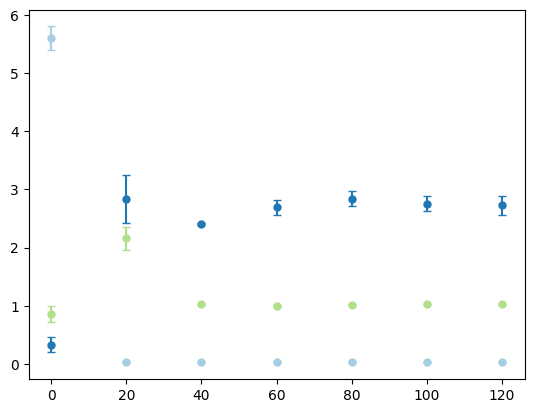

In [23]:
from chromatopy.units import mg_L, mM, uM
import pyenzyme as pe
time_sample_path = "data/time_sample/"
enzml_docs = []
# loop over all the time samples and create the ChromAnalyzer objects
for time_sample in os.listdir(time_sample_path):
    for data in analyzer_data:
        experiment_name = data["experiment_ name"] # check if the time sample matches the experiment name
        # if the time sample matches the experiment name, read the data and create the ChromAnalyzer
        if time_sample == experiment_name:
            data_path = os.path.join(time_sample_path, time_sample)
            # read the data and create the ChromAnalyzer object
            analyzer = ChromAnalyzer.read_agilent(
                path=data_path,
                ph=data["pH"],
                temperature=data["temperature"],
                mode="timecourse",
                )
            # add the salt to the analyzer
            salt = Molecule(
                id=data["salt"],
                name=data["salt"],
                pubchem_cid=data["salt_id"],
                init_conc=data["salt_conc [mM]"],
                conc_unit= mM,
            )
            analyzer.add_molecule(salt)
            # add the buffer to the analyzer
            buffer = Molecule(
                id=data["buffer"],
                name=data["buffer"],
                pubchem_cid=data["buffer_id"],
                init_conc=data["buffer_conc [mM]"],
                conc_unit= mM,
            )
            filtered_colors = {}
            analyzer.add_molecule(buffer)
            # substrates, intermdiates, and products are add to the analyzer
            for molecule_name in data["molecules"]:
                for molecule in molecules:
                    if molecule.id == molecule_name:
                        analyzer.add_molecule(molecule)
                        molecule = analyzer.get_molecule(molecule.id)
                        molecule.init_conc = data["Substrate_ini_conc [mM]"][
                            data["molecules"].index(molecule_name)
                        ]
                # filter the colors dictionary to only include the molecules that are in the analyzer for coloring the plots       
                for color_name in colors:
                    if molecule_name == color_name:
                        filtered_colors[molecule_name] = colors[color_name]
            #add ptotein data to the analyzer     
            for enzyme_name in analyzer_data[0]["enzyme_names"]:
                enzyme = Protein(
                    id=enzyme_name,
                    name=enzyme_name,
                    init_conc=analyzer_data[0]["enzyme_conc [uM]"][
                        analyzer_data[0]["enzyme_names"].index(enzyme_name)
                    ],
                    conc_unit= uM,
                )
                analyzer.add_protein(enzyme)
            # add the metadata to the timecourse data
            timecourse_enzymeML = to_enzymeml(
                document_name= "test",
                analyzers=analyzer,
                calculate_concentration=True,
                extrapolate=False,
             )


            
            # save the enzymeML document to file
            result_path = "result/enzymeML"
            # Create the directory if it doesn't exist
            if not os.path.exists(result_path):
                os.makedirs(result_path)
            # Save the enzymeML document as a JSON file
            with open(
                f"{result_path}/{data['experiment_ name']}.json",
                "w",
            ) as f:
                f.write(timecourse_enzymeML.model_dump_json())
            
            




             # Aggregate data for each molecule across measurements, averaging data for identical time points (e.g., 0)
            molecule_data = {
                species_id: {"time": [], "data": [], "std": []} for species_id in filtered_colors.keys()
            }
            for measurement in timecourse_enzymeML.measurements:
                for molecule in measurement.species_data:
                    if not molecule.data:  # skip molecules with no data
                        continue
                    # Group the values by time point.
                    grouped = {}
                    for t, d in zip(molecule.time, molecule.data):
                        grouped.setdefault(t, []).append(d)
                    # Create a sorted list of unique times and average the data for each time.
                    unique_times = sorted(grouped.keys())
                    averaged_times = []
                    averaged_data = []
                    std_data = []
                    for t in unique_times:
                        averaged_times.append(t)
                        averaged_data.append(np.mean(grouped[t]))
                        std_data.append(np.std(grouped[t]))
                    # Append the averaged times and data to the corresponding molecule's data 
                    molecule_data[molecule.species_id]["time"].append(averaged_times)
                    molecule_data[molecule.species_id]["data"].append(averaged_data)
                    molecule_data[molecule.species_id]["std"].append(std_data)
                    print(
                        f"Processed {molecule.species_id} at time {averaged_times} with data {averaged_data} and std {std_data}"
                    )
            # Define colors for each molecule
            # Plot mean as scatter points with error bars for standard deviation
            # Initialize a dictionary to store time and data values for each molecule across measurements
            
            # Plot mean and standard deviation for each molecule
            for species_id, data_dict in molecule_data.items():
                # Plot mean as scatter points with error bars for standard deviation
                color = colors[species_id]
                mean_time = np.array(data_dict["time"][0])
                mean_data = np.array(data_dict["data"][0])
                std_data = np.array(data_dict["std"][0])
                plt.errorbar(
                    mean_time,
                    mean_data,
                    yerr=std_data,
                    fmt="o",
                    color=color,
                    label=species_id,
                    ecolor=color,
                    capsize=3,
                    markersize=5,
                    alpha=1,
                    zorder=5,
                    clip_on=False,
                )

            # Set y-axis to start at zero
            plt.ylim(bottom=0)
            plt.xlim(left=0)

            # Customize and show the legend
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            plt.xlabel("Time [min]")
            plt.ylabel("Concentration [mM]")
            plt.legend(by_label.values(), by_label.keys())
            plt.savefig(
                f"{result_figure}/{meta_data['enzyme_name']}_concentration_course.png"
            )
            plt.show()
                    

            
                

   

## Get means and standard deviations among measurements with identical initial conditions